In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

dataset = fetch_ucirepo(id=601)

X = dataset.data.features
y = dataset.data.targets

df = pd.concat([X, y], axis=1)

df.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
df.shape

(10000, 12)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  str    
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float64
 5   Tool wear            10000 non-null  int64  
 6   Machine failure      10000 non-null  int64  
 7   TWF                  10000 non-null  int64  
 8   HDF                  10000 non-null  int64  
 9   PWF                  10000 non-null  int64  
 10  OSF                  10000 non-null  int64  
 11  RNF                  10000 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 947.4 KB


In [4]:
df.describe()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [5]:
df.columns.tolist()

['Type',
 'Air temperature',
 'Process temperature',
 'Rotational speed',
 'Torque',
 'Tool wear',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

## 2. Data Quality Analysis

In [6]:
df.isnull().sum()

Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Machine failure        0
TWF                    0
HDF                    0
PWF                    0
OSF                    0
RNF                    0
dtype: int64

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


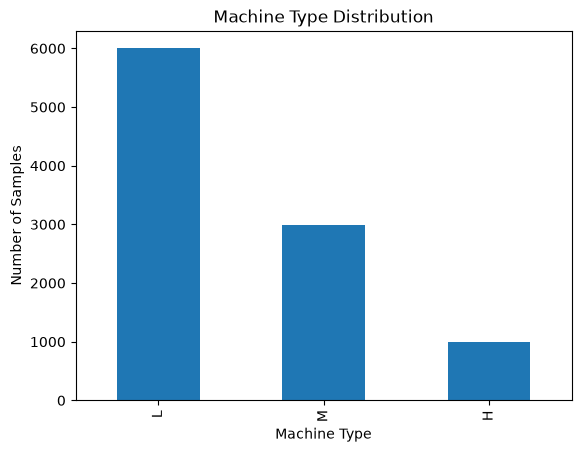

In [10]:
import matplotlib.pyplot as plt

df["Type"].value_counts().plot(kind="bar")

plt.title("Machine Type Distribution")
plt.xlabel("Machine Type")
plt.ylabel("Number of Samples")
plt.show()

In [11]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [12]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

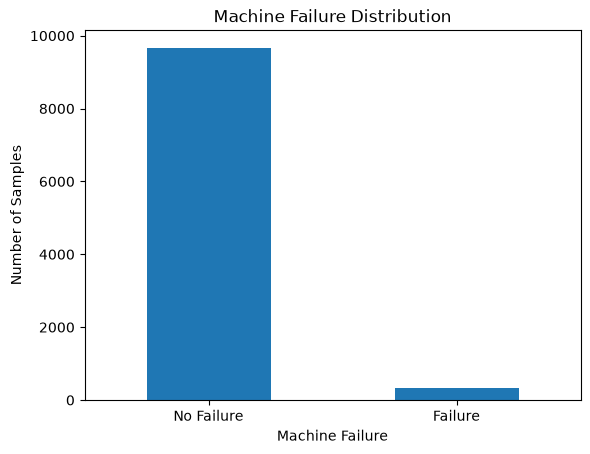

In [13]:
df["Machine failure"].value_counts().plot(
    kind="bar"
)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Number of Samples")
plt.xticks(
    ticks=[0, 1],
    labels=["No Failure", "Failure"],
    rotation=0
)

plt.show()

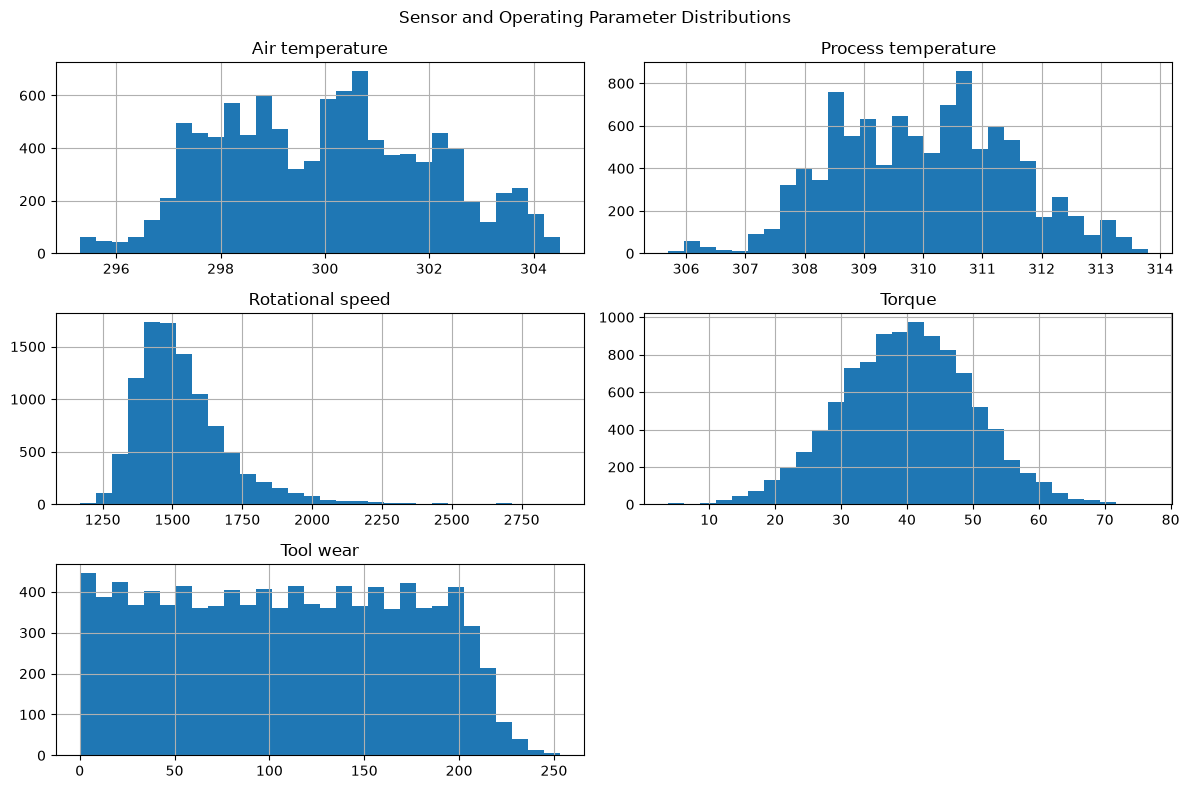

In [14]:
numeric_columns = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

df[numeric_columns].hist(
    figsize=(12, 8),
    bins=30
)

plt.suptitle("Sensor and Operating Parameter Distributions")
plt.tight_layout()
plt.show()

In [15]:
df.groupby("Machine failure")[numeric_columns].mean()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


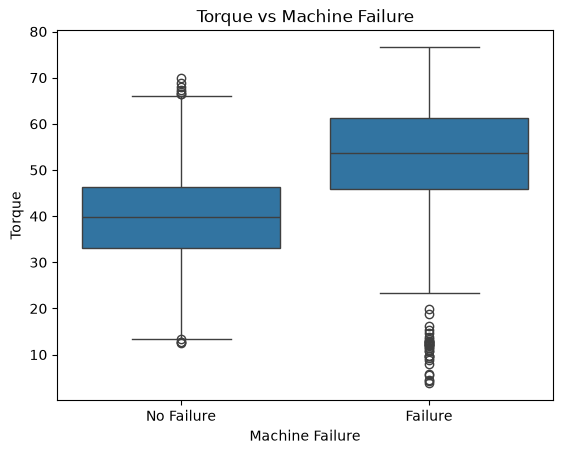

In [16]:
import seaborn as sns

sns.boxplot(
    data=df,
    x="Machine failure",
    y="Torque"
)

plt.title("Torque vs Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Torque")
plt.xticks(
    [0, 1],
    ["No Failure", "Failure"]
)

plt.show()

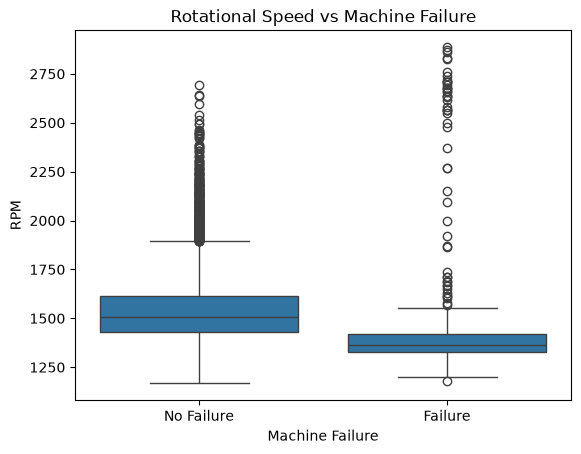

In [17]:
sns.boxplot(
    data=df,
    x="Machine failure",
    y="Rotational speed"
)

plt.title("Rotational Speed vs Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("RPM")
plt.xticks(
    [0, 1],
    ["No Failure", "Failure"]
)

plt.show()

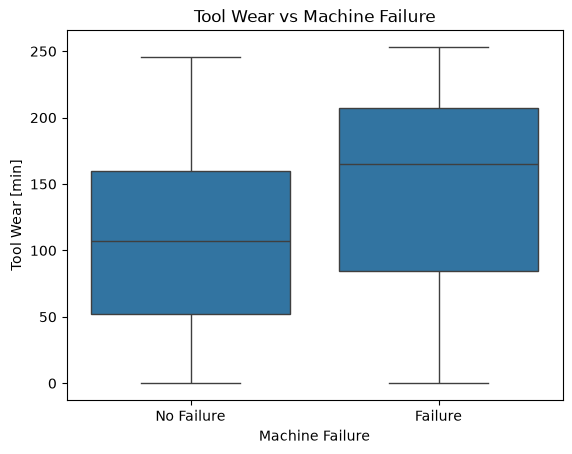

In [18]:
sns.boxplot(
    data=df,
    x="Machine failure",
    y="Tool wear"
)

plt.title("Tool Wear vs Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Tool Wear [min]")
plt.xticks(
    [0, 1],
    ["No Failure", "Failure"]
)

plt.show()

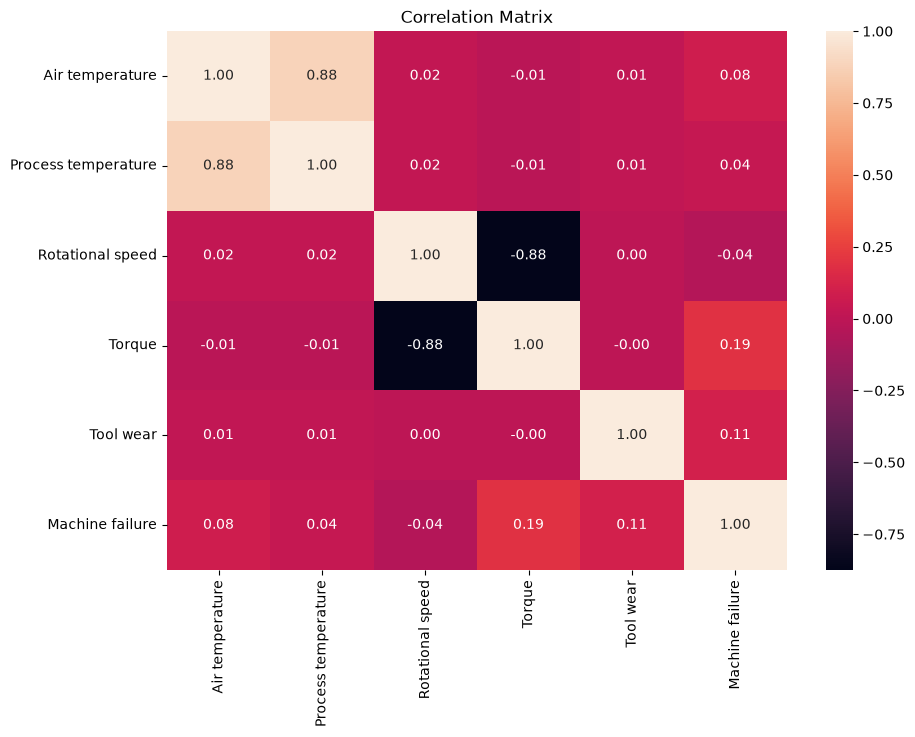

In [19]:
correlation = df[numeric_columns + ["Machine failure"]].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [20]:
failure_types = ["TWF", "HDF", "PWF", "OSF", "RNF"]

df[failure_types].sum().sort_values(ascending=False)

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

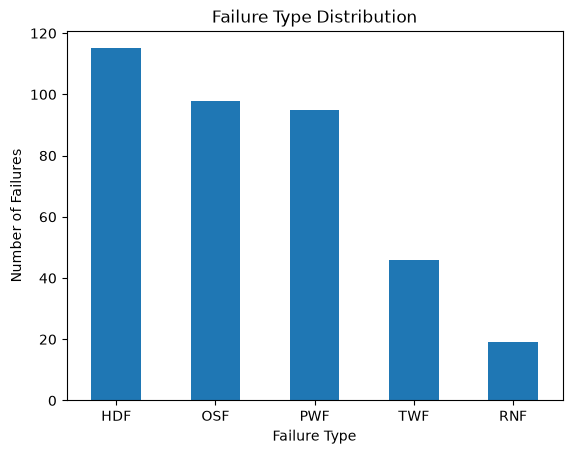

In [21]:
df[failure_types].sum().sort_values(ascending=False).plot(
    kind="bar"
)

plt.title("Failure Type Distribution")
plt.xlabel("Failure Type")
plt.ylabel("Number of Failures")
plt.xticks(rotation=0)

plt.show()

In [22]:
df.isnull().sum()

Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Machine failure        0
TWF                    0
HDF                    0
PWF                    0
OSF                    0
RNF                    0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [25]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [26]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [27]:
df.groupby("Machine failure")[numeric_columns].mean()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


## 3. Feature Engineering

Feature 1 — Temperature difference

In [28]:
df["Temperature Difference"] = (
    df["Process temperature"] - df["Air temperature"]
)

In [29]:
df["Temperature Difference"].describe()

count    10000.000000
mean        10.000630
std          1.001094
min          7.600000
25%          9.300000
50%          9.800000
75%         11.000000
max         12.100000
Name: Temperature Difference, dtype: float64

Feature 2 — Mechanical power

In [30]:
import numpy as np

df["Mechanical Power"] = (
    df["Torque"] *
    (2 * np.pi * df["Rotational speed"] / 60)
)

In [31]:
df["Mechanical Power kW"] = (
    df["Mechanical Power"] / 1000
)

In [32]:
df[
    [
        "Torque",
        "Rotational speed",
        "Mechanical Power kW"
    ]
].head()

,Torque,Rotational speed,Mechanical Power kW
0,42.8,1551,6.951591
1,46.3,1408,6.826723
2,49.4,1498,7.749388
3,39.5,1433,5.927505
4,40.0,1408,5.897817


Feature 3 — Temperature ratio

In [33]:
df["Temperature Ratio"] = (
    df["Process temperature"] /
    df["Air temperature"]
)

In [34]:
feature_columns = [
    "Type",
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear",
    "Temperature Difference",
    "Mechanical Power kW",
    "Temperature Ratio"
]

target_column = "Machine failure"

In [35]:
X = df[feature_columns]
y = df[target_column]

In [36]:
X.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Temperature Difference,Mechanical Power kW,Temperature Ratio
0,M,298.1,308.6,1551,42.8,0,10.5,6.951591,1.035223
1,L,298.2,308.7,1408,46.3,3,10.5,6.826723,1.035211
2,L,298.1,308.5,1498,49.4,5,10.4,7.749388,1.034888
3,L,298.2,308.6,1433,39.5,7,10.4,5.927505,1.034876
4,L,298.2,308.7,1408,40.0,9,10.5,5.897817,1.035211


In [37]:
y.value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
print("Training set:")
print(y_train.value_counts())

print("\nTest set:")
print(y_test.value_counts())

Training set:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Test set:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [40]:
df["Temperature Difference"] = (
    df["Process temperature"] - df["Air temperature"]
)

df["Mechanical Power"] = (
    df["Torque"] *
    (2 * np.pi * df["Rotational speed"] / 60)
)

df["Mechanical Power kW"] = (
    df["Mechanical Power"] / 1000
)

df["Temperature Ratio"] = (
    df["Process temperature"] /
    df["Air temperature"]
)

In [41]:
feature_columns = [
    "Type",
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear",
    "Temperature Difference",
    "Mechanical Power kW",
    "Temperature Ratio"
]

target_column = "Machine failure"

X = df[feature_columns]
y = df[target_column]

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
df[
    [
        "Temperature Difference",
        "Mechanical Power kW",
        "Temperature Ratio"
    ]
].describe()

,Temperature Difference,Mechanical Power kW,Temperature Ratio
count,10000.000000,10000.000000,10000.000000
mean,10.000630,6.279745,1.033352
std,1.001094,1.067418,0.003492
min,7.600000,1.148441,1.025116
25%,9.300000,5.561184,1.030686
50%,9.800000,6.271027,1.032847
75%,11.000000,7.003003,1.036777
max,12.100000,10.469923,1.040672


In [44]:
print(X_train.shape)
print(X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTest target:")
print(y_test.value_counts())

(8000, 9)
(2000, 9)

Training target:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Test target:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [46]:
categorical_features = ["Type"]

numerical_features = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear",
    "Temperature Difference",
    "Mechanical Power kW",
    "Temperature Ratio"
]

In [47]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [49]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [50]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Type','Air temperature','Process temperature',..., 'Temperature Difference','Mechanical Power kW','Temperature Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop

In [51]:
y_pred = logistic_model.predict(X_test)

In [52]:
y_proba = logistic_model.predict_proba(X_test)[:, 1]

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [54]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))
print("PR-AUC   :", average_precision_score(y_test, y_proba))

Accuracy : 0.859
Precision: 0.17771084337349397
Recall   : 0.8676470588235294
F1 Score : 0.295
ROC-AUC  : 0.9340062111801242
PR-AUC   : 0.4661818410305121


In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      1932
           1       0.18      0.87      0.29        68

    accuracy                           0.86      2000
   macro avg       0.59      0.86      0.61      2000
weighted avg       0.97      0.86      0.90      2000



In [56]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1659  273]
 [   9   59]]


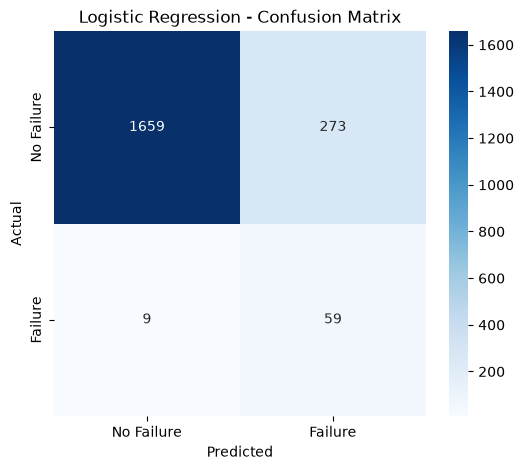

In [57]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [58]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
    "PR-AUC": average_precision_score(y_test, y_proba)
}

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.859,
 'Precision': 0.17771084337349397,
 'Recall': 0.8676470588235294,
 'F1': 0.295,
 'ROC-AUC': 0.9340062111801242,
 'PR-AUC': 0.4661818410305121}

In [59]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))
print("PR-AUC   :", average_precision_score(y_test, y_proba))

Accuracy : 0.859
Precision: 0.17771084337349397
Recall   : 0.8676470588235294
F1 Score : 0.295
ROC-AUC  : 0.9340062111801242
PR-AUC   : 0.4661818410305121


In [60]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      1932
           1       0.18      0.87      0.29        68

    accuracy                           0.86      2000
   macro avg       0.59      0.86      0.61      2000
weighted avg       0.97      0.86      0.90      2000



In [61]:
print(confusion_matrix(y_test, y_pred))

[[1659  273]
 [   9   59]]


In [ ]:
logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.859,
 'Precision': 0.17771084337349397,
 'Recall': 0.8676470588235294,
 'F1': 0.295,
 'ROC-AUC': 0.9340062111801242,
 'PR-AUC': 0.4661818410305121}